<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_047_gradient_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 47/365 — Gradient Boosting
## What if each new tree learned what the current model is still getting wrong?

Yesterday we learned **AdaBoost**.

Today we move to another major boosting method:

**Gradient Boosting**

For squared-error regression, the intuition is:

1. Make a prediction.
2. Calculate the residual: `actual - predicted`.
3. Train a small tree to learn those residuals.
4. Add part of that correction.
5. Repeat.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load the real Diabetes regression dataset


In [2]:
data=load_diabetes(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)

print("Dataset shape:",X.shape)
display(X.head())


Dataset shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Baseline: one Decision Tree


In [3]:
tree=DecisionTreeRegressor(max_depth=3,random_state=42)
tree.fit(X_train,y_train)

tree_train_pred=tree.predict(X_train)
tree_test_pred=tree.predict(X_test)

tree_train_rmse=mean_squared_error(y_train,tree_train_pred)**0.5
tree_test_rmse=mean_squared_error(y_test,tree_test_pred)**0.5

print("Tree Train RMSE:",round(tree_train_rmse,2))
print("Tree Test RMSE:",round(tree_test_rmse,2))


Tree Train RMSE: 54.45
Tree Test RMSE: 59.26


## 3. Train Gradient Boosting


In [4]:
gb=GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gb.fit(X_train,y_train)

gb_train_pred=gb.predict(X_train)
gb_test_pred=gb.predict(X_test)

gb_train_rmse=mean_squared_error(y_train,gb_train_pred)**0.5
gb_test_rmse=mean_squared_error(y_test,gb_test_pred)**0.5

print("Gradient Boosting Train RMSE:",round(gb_train_rmse,2))
print("Gradient Boosting Test RMSE:",round(gb_test_rmse,2))
print("Gradient Boosting Test R²:",round(r2_score(y_test,gb_test_pred),3))


Gradient Boosting Train RMSE: 45.4
Gradient Boosting Test RMSE: 53.89
Gradient Boosting Test R²: 0.475


## 4. Compare one tree vs Gradient Boosting


,Model,Train RMSE,Test RMSE
0,Decision Tree,54.45,59.26
1,Gradient Boosting,45.40,53.89


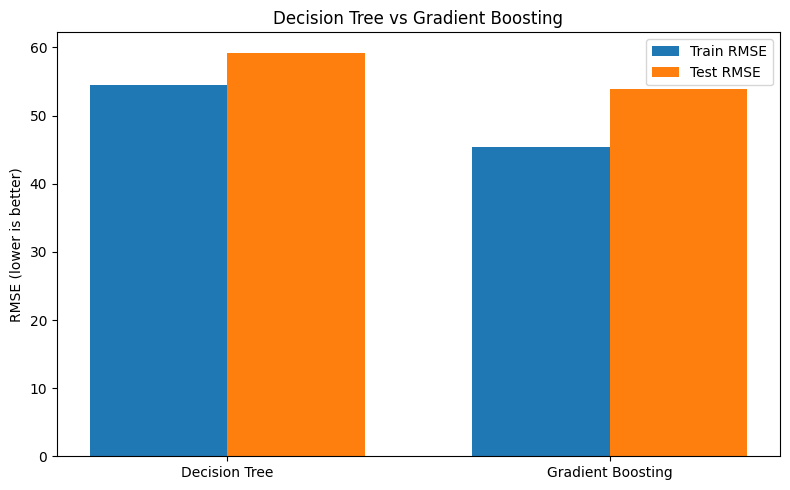

In [5]:
comparison=pd.DataFrame({
    "Model":["Decision Tree","Gradient Boosting"],
    "Train RMSE":[tree_train_rmse,gb_train_rmse],
    "Test RMSE":[tree_test_rmse,gb_test_rmse]
})

display(comparison.round(2))

x=np.arange(len(comparison))

plt.figure(figsize=(8,5))
plt.bar(x-0.18,comparison["Train RMSE"],width=0.36,label="Train RMSE")
plt.bar(x+0.18,comparison["Test RMSE"],width=0.36,label="Test RMSE")
plt.xticks(x,comparison["Model"])
plt.ylabel("RMSE (lower is better)")
plt.title("Decision Tree vs Gradient Boosting")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Watch the ensemble improve stage by stage

Each boosting stage adds another small tree.


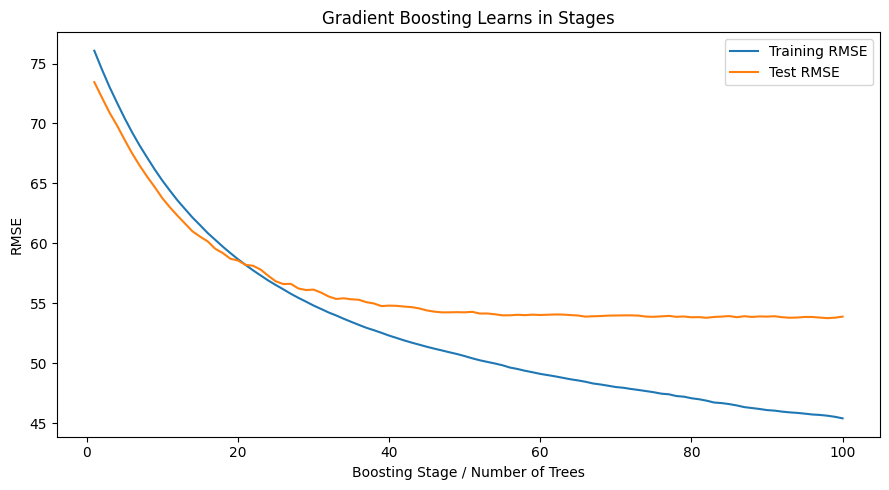

In [6]:
train_rmse=[]
test_rmse=[]

for p_train,p_test in zip(
    gb.staged_predict(X_train),
    gb.staged_predict(X_test)
):
    train_rmse.append(mean_squared_error(y_train,p_train)**0.5)
    test_rmse.append(mean_squared_error(y_test,p_test)**0.5)

stages=np.arange(1,len(train_rmse)+1)

plt.figure(figsize=(9,5))
plt.plot(stages,train_rmse,label="Training RMSE")
plt.plot(stages,test_rmse,label="Test RMSE")
plt.xlabel("Boosting Stage / Number of Trees")
plt.ylabel("RMSE")
plt.title("Gradient Boosting Learns in Stages")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Residual intuition

Suppose:

Actual value = 100  
Current prediction = 70

Then:

`Residual = 100 - 70 = 30`

If the next tree predicts a correction of 20 and:

`learning_rate = 0.1`

then:

`New prediction = 70 + (0.1 × 20) = 72`

The correction is gradual.


## AdaBoost vs Gradient Boosting

**AdaBoost**
- gives more emphasis to difficult observations
- combines weak learners using weighted contributions

**Gradient Boosting**
- reduces a loss function stage by stage
- each new learner targets the remaining error direction
- with squared-error regression, this is closely tied to residuals


## Enterprise intuition

Imagine predicting **insurance claim cost**.

The first model captures the broad pattern.

But perhaps it:
- underestimates some expensive claims
- overestimates routine claims
- misses interactions between features

The next tree learns patterns in those remaining errors.

Then another tree corrects what is still wrong.

The same idea is useful in:
- claim-cost prediction
- demand forecasting
- customer-value prediction
- risk scoring
- pricing models


## What does this teach?

- Gradient Boosting builds trees sequentially.
- Each stage tries to reduce the current model's loss.
- With squared-error regression, new trees can be understood as learning residuals.
- `learning_rate` controls how much each tree contributes.
- `n_estimators` controls how many correction stages are added.
- More trees are not automatically better.

> **Gradient Boosting builds many small trees that repeatedly correct the ensemble's remaining mistakes.**


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html
- https://scikit-learn.org/stable/modules/ensemble.html#gradient-tree-boosting
- https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boosting-machine/10.1214/aos/1013203451.full
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
